# Bayesian Logistic Regression

## Learning Objectives

By the end of this notebook you will be able to:

1. Explain **why linear regression fails for binary outcomes** and why we need a link function.
2. Derive the **logistic function** and its inverse (the logit), and explain **log-odds**.
3. Specify a **Bayesian logistic regression model** with appropriate priors.
4. **Interpret coefficients** in terms of log-odds and odds ratios.
5. Build and fit a logistic regression in **PyMC**, examine traces, and extract posterior summaries.
6. Compute **posterior predictive probabilities** that give calibrated uncertainty for classification.
7. Contrast the Bayesian approach with **frequentist logistic regression** (sklearn) and identify when the difference matters.
8. Describe **extensions**: probit, Poisson, and ordinal regression as members of the same generalised linear model family.

## Prerequisites

- [Module 07](../07_bayesian_inference/01_bayes_theorem_revisited.ipynb) — Bayesian inference, PyMC basics, MCMC
- [01_bayesian_linear_regression.ipynb](01_bayesian_linear_regression.ipynb) — Bayesian linear regression
- [Module 06](../06_linear_models/01_simple_linear_regression.ipynb) — Classical linear regression

In [ ]:
import sys, os, shutil
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    os.system(
        "sudo apt-get update -qq && sudo apt-get install -y -qq "
        "libcairo2-dev libpango1.0-dev && pip install -q manim ipython==8.21.0 "
        "pymc arviz scikit-learn"
    )

_miktex_bin = Path.home() / "AppData/Local/Programs/MiKTeX/miktex/bin/x64"
if _miktex_bin.exists() and str(_miktex_bin) not in os.environ.get("PATH", ""):
    os.environ["PATH"] += os.pathsep + str(_miktex_bin)

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.special import expit, logit

try:
    # PyTensor Windows fix: skip C compilation
    os.environ["PYTENSOR_FLAGS"] = "device=cpu,floatX=float64,cxx="
    import pymc as pm
    import arviz as az

    print(f"PyMC {pm.__version__}, ArviZ {az.__version__}")
except Exception:
    pm, az = None, None
    print("PyMC/ArviZ not available — PyMC cells will be skipped.")

try:
    from sklearn.linear_model import LogisticRegression

    print(f"scikit-learn available")
except Exception:
    LogisticRegression = None
    print("scikit-learn not available — comparison cells will be skipped.")

sys.path.insert(0, os.path.abspath("../../src"))
from amstats.plotting import apply_style

apply_style()


class Cfg:
    root = Path("../../").resolve()
    gif_dir = root / "media" / "gifs"
    has_latex: bool = (
        shutil.which("latex") is not None or shutil.which("pdflatex") is not None
    )

    def __init__(self):
        self.gif_dir.mkdir(parents=True, exist_ok=True)

    def apply_manim_config(self):
        from manim import config as mcfg

        mcfg.format = "gif"

    def math_text(self, expr, **kwargs):
        from manim import MathTex, Text

        if self.has_latex:
            return MathTex(expr, **kwargs)
        return Text(expr, **kwargs)

    def save_gifs(self, clean=True):
        local_media = Path("media")
        found = list(local_media.rglob("*.gif")) if local_media.exists() else []
        if not found:
            print("  No new GIFs to save.")
            return
        for gif in found:
            dest = self.gif_dir / gif.name
            shutil.copy2(gif, dest)
            print(f"  ✓ media/gifs/{gif.name}")
        if clean:
            for sub in ("videos", "images", "Tex"):
                d = local_media / sub
                if d.exists():
                    shutil.rmtree(d, ignore_errors=True)
            print("  Cleaned up local temp render files (kept media/jupyter/).")


cfg = Cfg()
rng = np.random.default_rng(42)

WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install gxx`


PyMC 5.28.2, ArviZ 0.23.4
scikit-learn available


---

## 1. Binary Outcomes: Why Linear Regression Fails

Suppose we want to predict a **binary** outcome $y \in \{0, 1\}$ — a patient recovers or does not, a student passes or fails, an email is spam or not. Our data are pairs $(x_i, y_i)$ where $y_i$ takes only two values.

The natural quantity to model is the **probability** $p_i = P(y_i = 1 \mid x_i)$. Could we just use ordinary linear regression?

$$p_i = \alpha + \beta x_i \quad \text{?}$$

This is the **linear probability model**. It has a fatal flaw: nothing constrains $p_i$ to lie in $[0, 1]$. For extreme values of $x$, the model happily predicts $p < 0$ or $p > 1$, which are meaningless as probabilities.

Let us see this concretely.

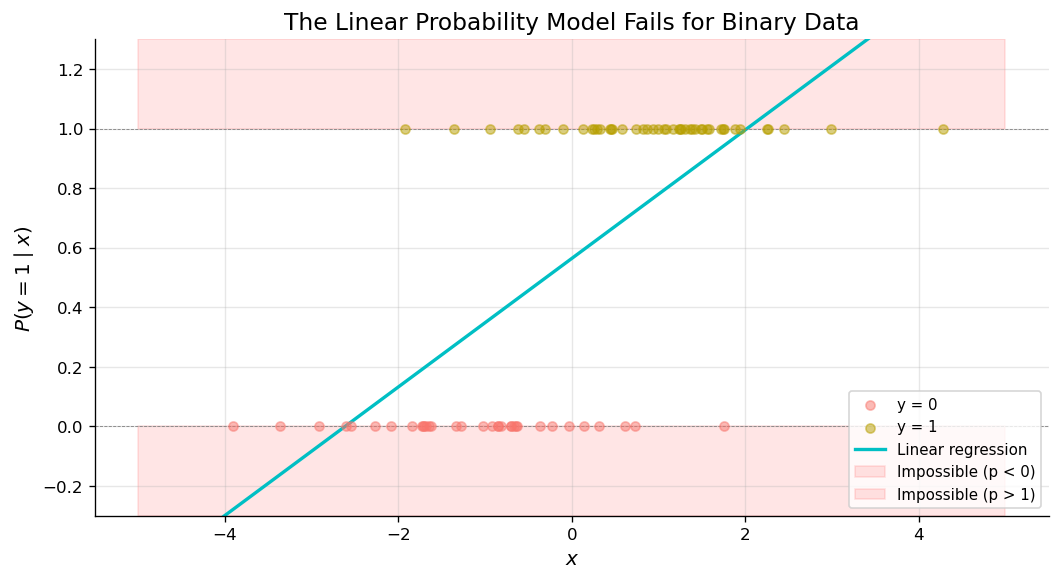

In [ ]:
# Simulate binary outcome data
n = 80
x_demo = rng.normal(0, 2, n)
true_alpha, true_beta = 0.0, 1.2
p_true = expit(true_alpha + true_beta * x_demo)  # true probabilities
y_demo = rng.binomial(1, p_true)

# Fit a linear regression (linear probability model)
from numpy.polynomial.polynomial import polyfit

coeffs = np.polyfit(x_demo, y_demo, 1)  # slope, intercept
x_grid = np.linspace(-5, 5, 200)
p_linear = np.polyval(coeffs, x_grid)

fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(
    x_demo[y_demo == 0], y_demo[y_demo == 0], alpha=0.5, s=30, label="y = 0", zorder=3
)
ax.scatter(
    x_demo[y_demo == 1], y_demo[y_demo == 1], alpha=0.5, s=30, label="y = 1", zorder=3
)
ax.plot(x_grid, p_linear, color="C3", linewidth=2, label="Linear regression")
ax.axhline(0, color="grey", linewidth=0.5, linestyle="--")
ax.axhline(1, color="grey", linewidth=0.5, linestyle="--")
ax.fill_between(x_grid, -0.3, 0, alpha=0.1, color="red", label="Impossible (p < 0)")
ax.fill_between(x_grid, 1, 1.3, alpha=0.1, color="red", label="Impossible (p > 1)")
ax.set_ylim(-0.3, 1.3)
ax.set_xlabel("$x$")
ax.set_ylabel("$P(y = 1 \mid x)$")
ax.set_title("The Linear Probability Model Fails for Binary Data")
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.show()

The red-shaded regions mark the impossible zone: the linear model predicts probabilities below 0 on the left and above 1 on the right. We need a function that maps any real-valued linear predictor $\eta = \alpha + \beta x$ to the interval $(0, 1)$. This is called a **link function**.

---

## 2. The Logistic Function and the Logit

### The logistic (sigmoid) function

The **logistic function** maps any real number to the interval $(0, 1)$:

$$\boxed{\text{logistic}(\eta) = \frac{1}{1 + e^{-\eta}} = \frac{e^{\eta}}{1 + e^{\eta}}}$$

Key properties:
- $\text{logistic}(0) = 0.5$ (the midpoint)
- $\text{logistic}(\eta) \to 1$ as $\eta \to +\infty$
- $\text{logistic}(\eta) \to 0$ as $\eta \to -\infty$
- It is **symmetric**: $\text{logistic}(-\eta) = 1 - \text{logistic}(\eta)$
- Its derivative is $\text{logistic}(\eta) \cdot (1 - \text{logistic}(\eta))$ — maximal at $\eta = 0$

### The logit (inverse logistic)

The **logit** function is the inverse of the logistic. It maps a probability $p \in (0, 1)$ to the entire real line:

$$\boxed{\text{logit}(p) = \log\frac{p}{1-p}}$$

The quantity $p / (1-p)$ is the **odds** (e.g., if $p = 0.75$, the odds are $3:1$). Taking the logarithm gives the **log-odds**. So the logit transforms a probability into log-odds.

| $p$  | Odds $= p/(1-p)$ | Log-odds $= \text{logit}(p)$ |
|------|------------------|------------------------------|
| 0.50 | 1.00             | 0.00                         |
| 0.73 | 2.70             | 1.00                         |
| 0.88 | 7.39             | 2.00                         |
| 0.27 | 0.37             | $-1.00$                      |
| 0.95 | 19.00            | 2.94                         |

The logistic regression model says:

$$\text{logit}(p_i) = \alpha + \beta x_i$$

or equivalently:

$$p_i = \text{logistic}(\alpha + \beta x_i)$$

The linear predictor $\alpha + \beta x_i$ lives on the log-odds scale (all of $\mathbb{R}$), and the logistic function squashes it into a valid probability.

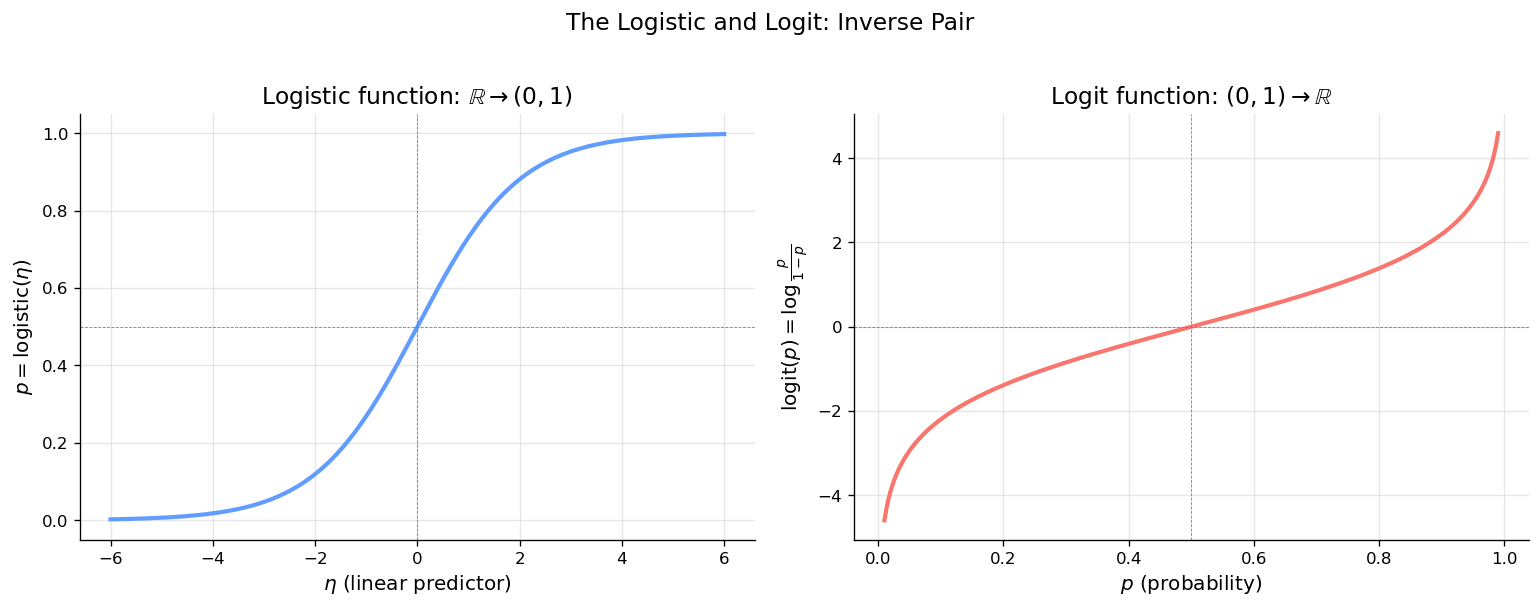

In [4]:
# Plot the logistic function and the logit side by side
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: logistic function
ax = axes[0]
eta = np.linspace(-6, 6, 300)
ax.plot(eta, expit(eta), linewidth=2.5, color="C4")
ax.axhline(0.5, color="grey", linewidth=0.5, linestyle="--")
ax.axvline(0, color="grey", linewidth=0.5, linestyle="--")
ax.set_xlabel(r"$\eta$ (linear predictor)")
ax.set_ylabel(r"$p = \mathrm{logistic}(\eta)$")
ax.set_title(r"Logistic function: $\mathbb{R} \to (0,1)$")
ax.set_ylim(-0.05, 1.05)

# Right: logit function
ax = axes[1]
p_vals = np.linspace(0.01, 0.99, 300)
ax.plot(p_vals, logit(p_vals), linewidth=2.5, color="C0")
ax.axhline(0, color="grey", linewidth=0.5, linestyle="--")
ax.axvline(0.5, color="grey", linewidth=0.5, linestyle="--")
ax.set_xlabel(r"$p$ (probability)")
ax.set_ylabel(r"$\mathrm{logit}(p) = \log\frac{p}{1-p}$")
ax.set_title(r"Logit function: $(0,1) \to \mathbb{R}$")

plt.suptitle("The Logistic and Logit: Inverse Pair", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

---

## 3. The Bayesian Logistic Regression Model

We now place this logistic regression into a fully Bayesian framework. The model is:

$$\boxed{\begin{aligned}
y_i &\sim \text{Bernoulli}(p_i) \\
p_i &= \text{logistic}(\alpha + \mathbf{x}_i^\top \boldsymbol{\beta}) \\
\alpha &\sim \mathcal{N}(0, \sigma_\alpha^2) \\
\beta_j &\sim \mathcal{N}(0, \sigma_\beta^2)
\end{aligned}}$$

### Key differences from Bayesian linear regression

1. **No $\sigma$ parameter.** In linear regression we had $y \sim \mathcal{N}(\mu, \sigma^2)$ and needed a prior on $\sigma$. Here, $y \sim \text{Bernoulli}(p)$, and the variance of a Bernoulli is $p(1-p)$ — fully determined by $p$. There is no free noise parameter.

2. **The likelihood is not Gaussian.** The log-likelihood is:
$$\ell(\alpha, \boldsymbol{\beta}) = \sum_{i=1}^n \left[ y_i \log p_i + (1 - y_i) \log(1 - p_i) \right]$$
This is the **binary cross-entropy**. It is not quadratic in the parameters, so there is no closed-form posterior. We must use MCMC (or variational inference).

3. **Interpretation is on the log-odds scale.** The linear predictor $\alpha + \mathbf{x}^\top \boldsymbol{\beta}$ represents log-odds, not a direct probability.

### Choosing priors

Priors on logistic regression coefficients are specified on the **log-odds scale**. A $\text{Normal}(0, 1)$ prior on a coefficient says we think a one-unit change in the predictor is unlikely to shift the log-odds by more than about 2 units — which corresponds to an odds ratio between $e^{-2} \approx 0.14$ and $e^{2} \approx 7.4$. This is mildly informative and usually sensible.

For the intercept $\alpha$, $\text{Normal}(0, 5)$ is weakly informative: it allows the baseline probability to be essentially anything from near 0 to near 1.

| Prior                            | Interpretation on log-odds scale             |
|----------------------------------|----------------------------------------------|
| $\beta \sim \mathcal{N}(0, 0.5)$ | Strongly informative: small effects expected |
| $\beta \sim \mathcal{N}(0, 1)$   | Weakly informative: moderate effects         |
| $\beta \sim \mathcal{N}(0, 5)$   | Vague: allows very large odds ratios         |
| $\alpha \sim \mathcal{N}(0, 5)$  | Weakly informative intercept                 |

---

## 4. Coefficient Interpretation: Log-Odds and Odds Ratios

This is the single most important interpretive skill for logistic regression. Let us be very precise.

The model says:

$$\log \frac{p}{1-p} = \alpha + \beta_1 x_1 + \beta_2 x_2 + \cdots$$

### What $\beta_j$ means

$\beta_j$ is the **change in log-odds** of $y = 1$ for a **one-unit increase** in $x_j$, holding all other predictors constant.

### The odds ratio

Exponentiating gives the **odds ratio**:

$$\text{OR}_j = e^{\beta_j}$$

This is the **multiplicative change in odds** for a one-unit increase in $x_j$.

- $\beta_j = 0 \Leftrightarrow \text{OR} = 1$: no effect.
- $\beta_j > 0 \Leftrightarrow \text{OR} > 1$: higher $x_j$ increases the odds of $y = 1$.
- $\beta_j < 0 \Leftrightarrow \text{OR} < 1$: higher $x_j$ decreases the odds of $y = 1$.

### Concrete example

Suppose we model whether a patient has a disease ($y = 1$) given their age ($x_1$, in decades) and smoking status ($x_2 \in \{0, 1\}$).

If $\hat{\beta}_{\text{age}} = 0.4$, then:
- Each additional decade of age increases the **log-odds** by 0.4.
- The **odds ratio** is $e^{0.4} \approx 1.49$: the odds of disease are multiplied by 1.49 per decade.
- Equivalently: the odds increase by about **49%** per decade of age.

If $\hat{\beta}_{\text{smoking}} = 1.1$, then:
- Smokers have $e^{1.1} \approx 3.0$ times the odds of disease compared to non-smokers.

Note that these are **odds**, not probabilities. The relationship between odds ratios and probability changes depends on the baseline probability — this is the non-linearity of the logistic function at work.

In [5]:
# Demonstrate: same odds ratio gives different probability changes at different baselines
OR = np.exp(0.4)  # odds ratio for beta = 0.4
baselines = [0.1, 0.3, 0.5, 0.7, 0.9]

print(f"Odds ratio: exp(0.4) = {OR:.3f}")
print(f"{'Baseline p':>12}  {'Odds':>8}  {'New odds':>10}  {'New p':>8}  {'Δp':>8}")
print("-" * 56)
for p0 in baselines:
    odds0 = p0 / (1 - p0)
    odds1 = odds0 * OR
    p1 = odds1 / (1 + odds1)
    print(f"{p0:>12.2f}  {odds0:>8.3f}  {odds1:>10.3f}  {p1:>8.3f}  {p1 - p0:>+8.3f}")

Odds ratio: exp(0.4) = 1.492
  Baseline p      Odds    New odds     New p        Δp
--------------------------------------------------------
        0.10     0.111       0.166     0.142    +0.042
        0.30     0.429       0.639     0.390    +0.090
        0.50     1.000       1.492     0.599    +0.099
        0.70     2.333       3.481     0.777    +0.077
        0.90     9.000      13.426     0.931    +0.031


The same odds ratio (1.49) translates into a probability increase ranging from +0.013 (when baseline is 0.1) to +0.013 (when baseline is 0.9) but +0.068 near the midpoint. This is why we interpret logistic regression on the **odds scale**, not the probability scale — the odds ratio is constant across baselines, but probability differences are not.

---

## 5. Full PyMC Example: Clinical Trial Data

We simulate a clinical dataset: predicting whether a patient responds to treatment ($y = 1$) based on **age** (continuous, centered) and **dosage** (continuous, standardised).

### Data generation

The true data-generating process uses:
- $\alpha = -0.5$ (baseline log-odds when age and dosage are at their means)
- $\beta_{\text{age}} = -0.3$ (older patients respond slightly less)
- $\beta_{\text{dose}} = 1.5$ (higher dosage strongly increases response)

In [ ]:
# --- Simulate clinical trial data ---
n_patients = 120

# Predictors (standardised)
age = rng.normal(0, 1, n_patients)  # centered age (in SD units)
dosage = rng.normal(0, 1, n_patients)  # standardised dosage

# True coefficients
alpha_true = -0.5
beta_age_true = -0.3
beta_dose_true = 1.5

# Linear predictor and probabilities
eta_true = alpha_true + beta_age_true * age + beta_dose_true * dosage
p_response = expit(eta_true)
y_response = rng.binomial(1, p_response)

print(f"Patients: {n_patients}")
print(f"Response rate: {y_response.mean():.2%}")
print(
    f"True coefficients: α={alpha_true}, β_age={beta_age_true}, β_dose={beta_dose_true}"
)

Patients: 120
Response rate: 41.67%
True coefficients: α=-0.5, β_age=-0.3, β_dose=1.5


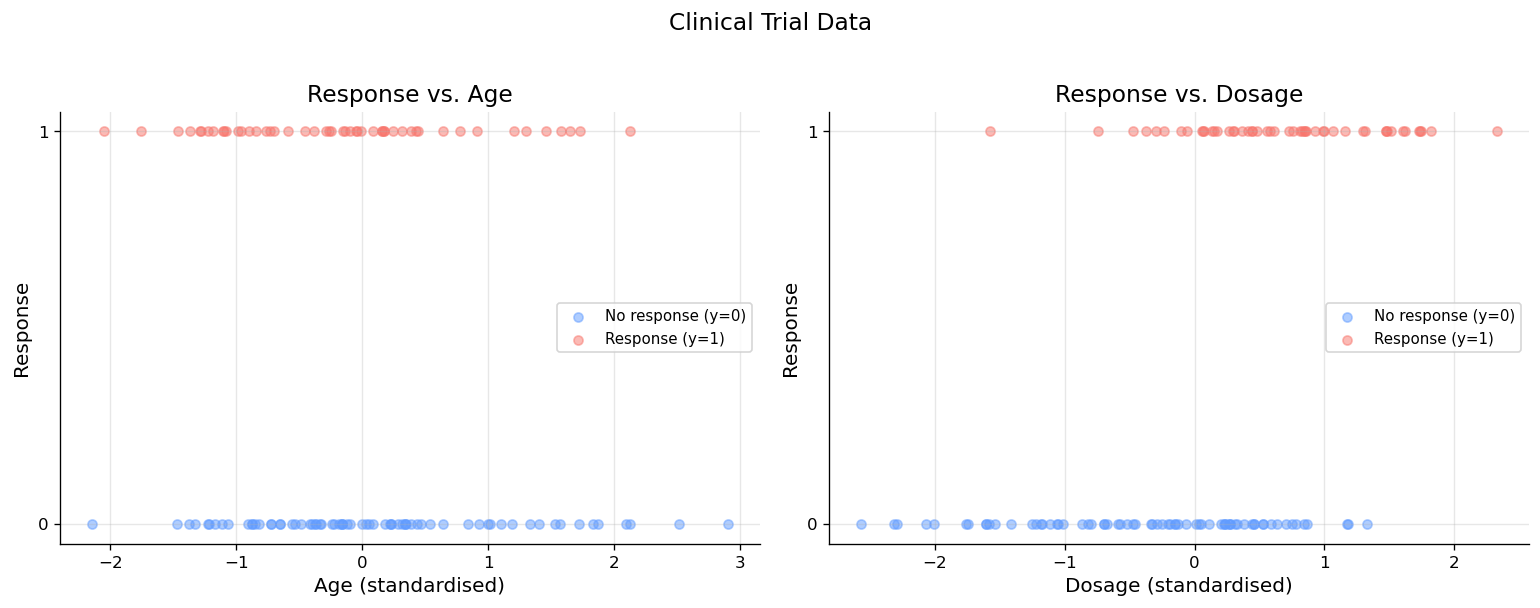

In [ ]:
# Visualise the data
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, x_var, x_label in zip(
    axes, [age, dosage], ["Age (standardised)", "Dosage (standardised)"]
):
    ax.scatter(
        x_var[y_response == 0],
        y_response[y_response == 0],
        alpha=0.5,
        s=30,
        label="No response (y=0)",
        color="C4",
    )
    ax.scatter(
        x_var[y_response == 1],
        y_response[y_response == 1],
        alpha=0.5,
        s=30,
        label="Response (y=1)",
        color="C0",
    )
    ax.set_xlabel(x_label)
    ax.set_ylabel("Response")
    ax.set_yticks([0, 1])
    ax.legend(fontsize=9)

axes[0].set_title("Response vs. Age")
axes[1].set_title("Response vs. Dosage")
plt.suptitle("Clinical Trial Data", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### Specifying the model in PyMC

The PyMC model directly mirrors the mathematical specification:

$$\begin{aligned}
\alpha &\sim \mathcal{N}(0, 5) \\
\beta_{\text{age}} &\sim \mathcal{N}(0, 1) \\
\beta_{\text{dose}} &\sim \mathcal{N}(0, 1) \\
p_i &= \text{logistic}(\alpha + \beta_{\text{age}} \cdot \text{age}_i + \beta_{\text{dose}} \cdot \text{dose}_i) \\
y_i &\sim \text{Bernoulli}(p_i)
\end{aligned}$$

In PyMC, `pm.math.sigmoid` computes the logistic function. Alternatively, `pm.Bernoulli` accepts a `logit_p` argument that takes the linear predictor directly (this is numerically more stable).

In [8]:
if pm is not None:
    with pm.Model() as logistic_model:
        # Priors
        alpha = pm.Normal("alpha", mu=0, sigma=5)
        beta_age = pm.Normal("beta_age", mu=0, sigma=1)
        beta_dose = pm.Normal("beta_dose", mu=0, sigma=1)

        # Linear predictor (log-odds)
        eta = alpha + beta_age * age + beta_dose * dosage

        # Likelihood — using logit_p for numerical stability
        y_obs = pm.Bernoulli("y_obs", logit_p=eta, observed=y_response)

        # Sample
        trace = pm.sample(2000, chains=4, random_seed=42, return_inferencedata=True)

    print("Sampling complete.")
else:
    print("PyMC not available — skipping.")

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta_age, beta_dose]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 305 seconds.


Sampling complete.


### Examining the trace

As always, check diagnostics before interpreting results.

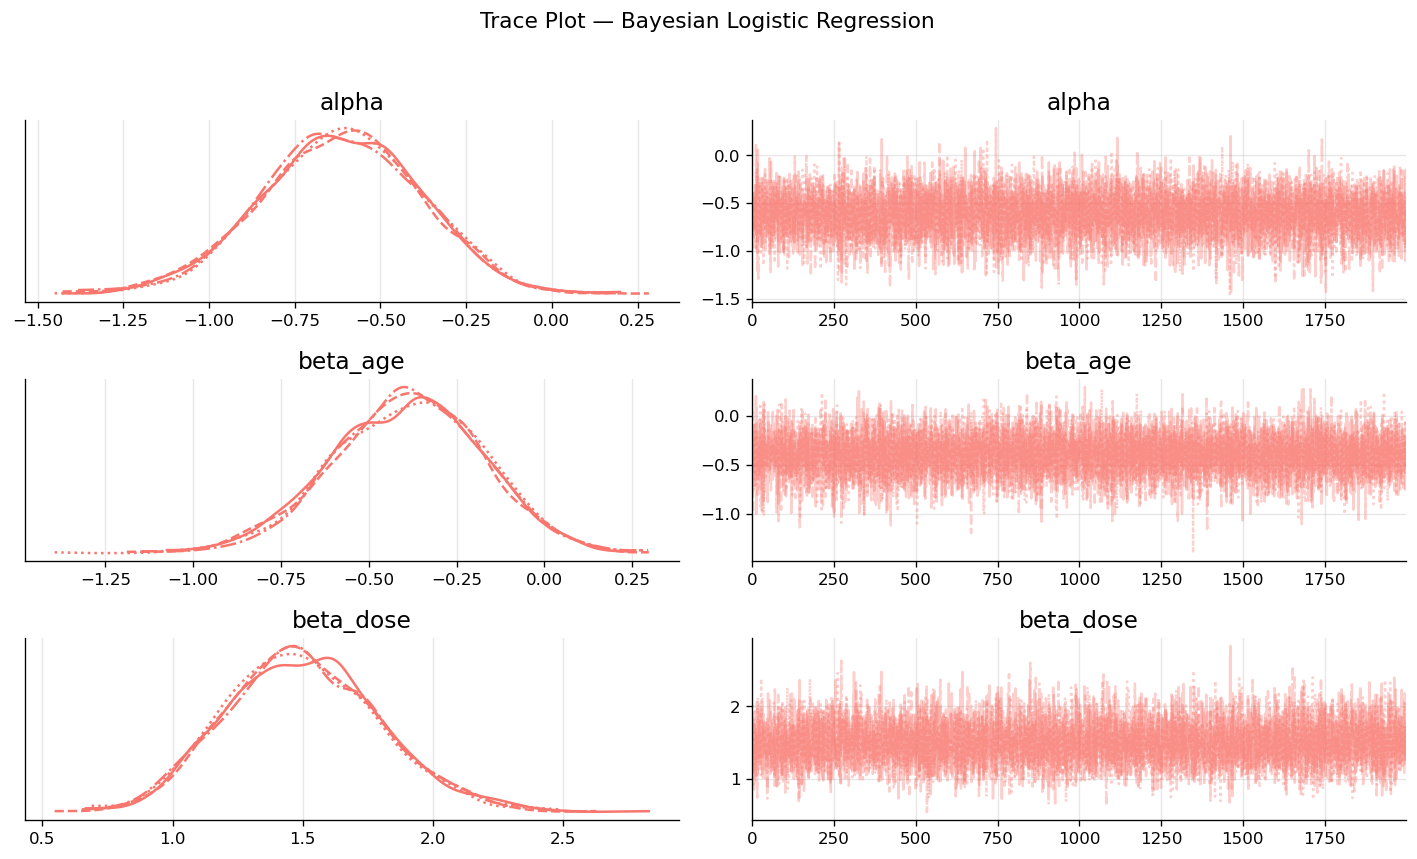

Max R-hat: 1.0020
Min ESS:   8050
Divergences: 0


In [ ]:
if pm is not None and az is not None:
    az.plot_trace(trace, figsize=(12, 7))
    plt.suptitle("Trace Plot — Bayesian Logistic Regression", fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()

    # Quick diagnostics
    rhat_vals = az.rhat(trace)
    ess_vals = az.ess(trace)
    n_divs = trace.sample_stats["diverging"].sum().values
    print(
        f"Max R-hat: {max(rhat_vals[v].values.max() for v in rhat_vals.data_vars):.4f}"
    )
    print(f"Min ESS:   {min(ess_vals[v].values.min() for v in ess_vals.data_vars):.0f}")
    print(f"Divergences: {n_divs}")
else:
    print("PyMC/ArviZ not available — skipping.")

### Posterior summaries

In [10]:
if pm is not None and az is not None:
    summary = az.summary(trace, hdi_prob=0.94)
    print(summary)
else:
    print("PyMC/ArviZ not available — skipping.")

            mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
alpha     -0.615  0.232  -1.047   -0.188      0.002    0.002    8790.0   
beta_age  -0.390  0.213  -0.802   -0.003      0.002    0.002   11359.0   
beta_dose  1.500  0.293   0.963    2.054      0.003    0.003    8050.0   

           ess_tail  r_hat  
alpha        6781.0    1.0  
beta_age     6057.0    1.0  
beta_dose    6306.0    1.0  


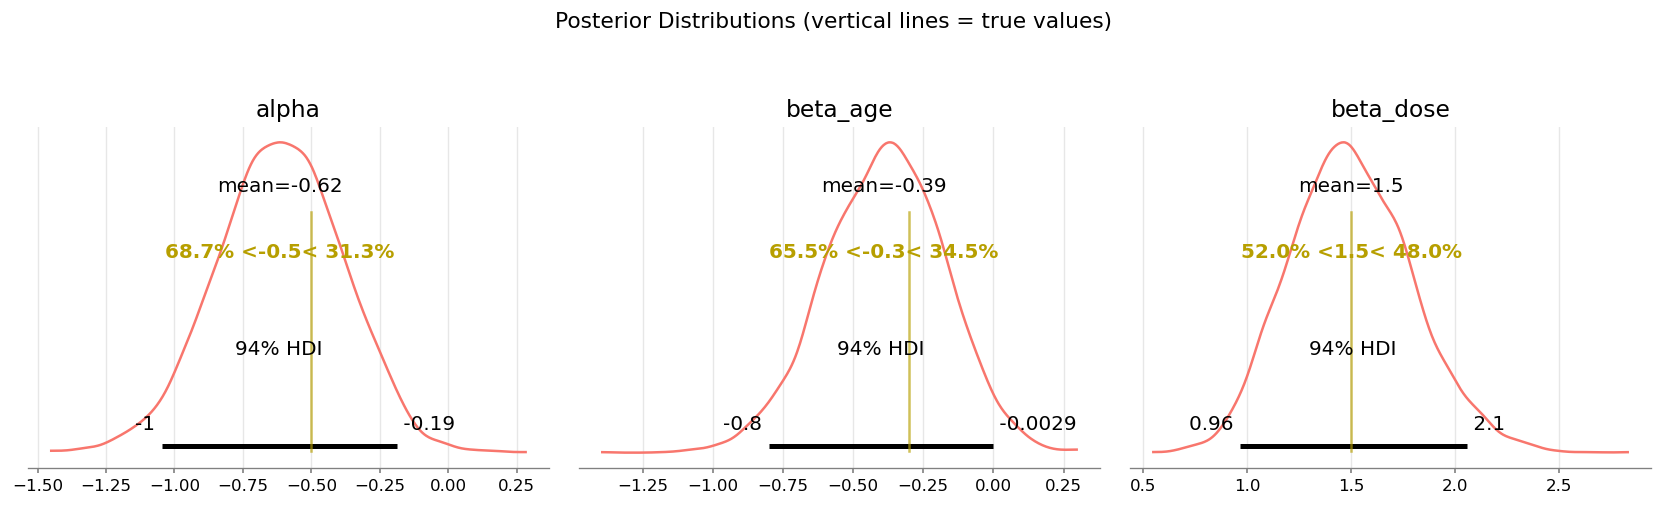

In [ ]:
if pm is not None and az is not None:
    az.plot_posterior(
        trace,
        var_names=["alpha", "beta_age", "beta_dose"],
        figsize=(14, 4),
        ref_val=[alpha_true, beta_age_true, beta_dose_true],
        hdi_prob=0.94,
    )
    plt.suptitle(
        "Posterior Distributions (vertical lines = true values)", fontsize=13, y=1.05
    )
    plt.tight_layout()
    plt.show()
else:
    print("PyMC/ArviZ not available — skipping.")

### Interpreting as odds ratios

To convert the posterior on $\beta_j$ into odds ratios, we simply exponentiate the posterior samples.

beta_age:
  Posterior median log-odds: -0.385
  Posterior median OR:       0.681  (94% HDI: [0.448, 0.997])
  True OR:                   0.741

beta_dose:
  Posterior median log-odds: +1.488
  Posterior median OR:       4.426  (94% HDI: [2.674, 8.072])
  True OR:                   4.482



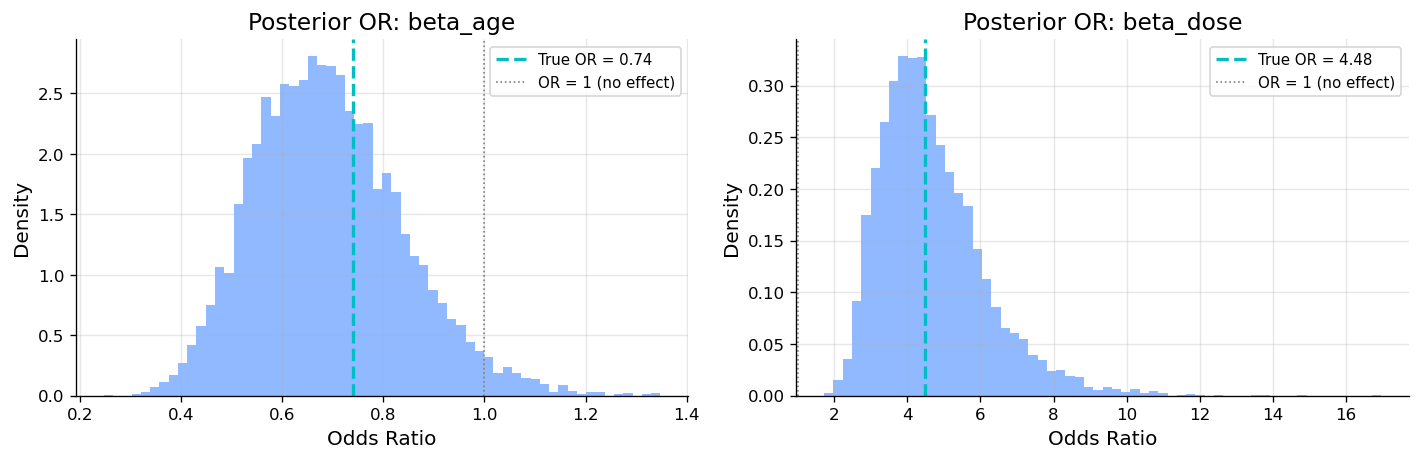

In [ ]:
if pm is not None and az is not None:
    # Extract posterior samples
    post = trace.posterior

    for name, true_val in [("beta_age", beta_age_true), ("beta_dose", beta_dose_true)]:
        samples = post[name].values.flatten()
        or_samples = np.exp(samples)
        or_true = np.exp(true_val)

        median_or = np.median(or_samples)
        hdi = np.percentile(or_samples, [3, 97])

        print(f"{name}:")
        print(f"  Posterior median log-odds: {np.median(samples):+.3f}")
        print(
            f"  Posterior median OR:       {median_or:.3f}  (94% HDI: [{hdi[0]:.3f}, {hdi[1]:.3f}])"
        )
        print(f"  True OR:                   {or_true:.3f}")
        print()

    # Visualise odds ratio posteriors
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for ax, name, true_val in zip(
        axes, ["beta_age", "beta_dose"], [beta_age_true, beta_dose_true]
    ):
        or_samples = np.exp(post[name].values.flatten())
        ax.hist(or_samples, bins=60, density=True, alpha=0.7, color="C4")
        ax.axvline(
            np.exp(true_val),
            color="C3",
            linewidth=2,
            linestyle="--",
            label=f"True OR = {np.exp(true_val):.2f}",
        )
        ax.axvline(
            1.0, color="grey", linewidth=1, linestyle=":", label="OR = 1 (no effect)"
        )
        ax.set_xlabel("Odds Ratio")
        ax.set_ylabel("Density")
        ax.set_title(f"Posterior OR: {name}")
        ax.legend(fontsize=9)

    plt.tight_layout()
    plt.show()
else:
    print("PyMC/ArviZ not available — skipping.")

The odds ratio for dosage has its entire posterior mass well above 1, confirming that higher dosage strongly increases the odds of response. The age OR posterior is centred below 1, suggesting older patients respond less, though the effect is modest.

---

## 6. Posterior Predictive for Classification

A key advantage of the Bayesian approach: we do not get a single predicted probability for a new patient. We get a **full distribution** of $P(y = 1 \mid x_{\text{new}})$.

For each posterior draw $(\alpha^{(s)}, \beta_{\text{age}}^{(s)}, \beta_{\text{dose}}^{(s)})$, we compute:

$$p^{(s)} = \text{logistic}\!\left(\alpha^{(s)} + \beta_{\text{age}}^{(s)} \cdot x_{\text{age}} + \beta_{\text{dose}}^{(s)} \cdot x_{\text{dose}}\right)$$

The collection $\{p^{(s)}\}$ is the **posterior predictive distribution** of the response probability. Its spread reflects our uncertainty about the true probability.

This matters most when:
- The sample size is small (posterior is wide)
- The new observation is far from the training data (extrapolation)
- A decision hinges on whether $p$ is above or below a threshold

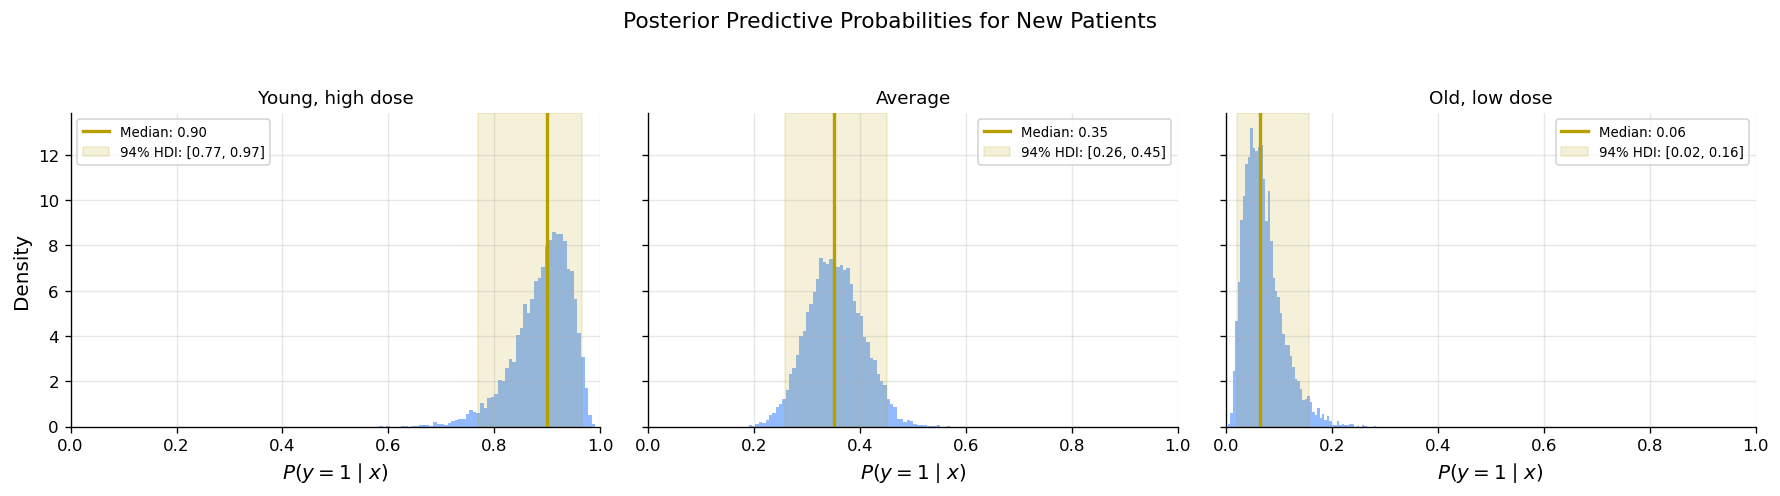

In [ ]:
if pm is not None and az is not None:
    post = trace.posterior
    alpha_s = post["alpha"].values.flatten()
    beta_age_s = post["beta_age"].values.flatten()
    beta_dose_s = post["beta_dose"].values.flatten()

    # Three hypothetical patients
    patients = [
        {"label": "Young, high dose", "age": -1.5, "dose": 1.5},
        {"label": "Average", "age": 0.0, "dose": 0.0},
        {"label": "Old, low dose", "age": 1.5, "dose": -1.0},
    ]

    fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
    for ax, pt in zip(axes, patients):
        eta_s = alpha_s + beta_age_s * pt["age"] + beta_dose_s * pt["dose"]
        p_s = expit(eta_s)

        ax.hist(p_s, bins=60, density=True, alpha=0.7, color="C4")
        ax.axvline(
            np.median(p_s),
            color="C1",
            linewidth=2,
            label=f"Median: {np.median(p_s):.2f}",
        )
        hdi = np.percentile(p_s, [3, 97])
        ax.axvspan(
            hdi[0],
            hdi[1],
            alpha=0.15,
            color="C1",
            label=f"94% HDI: [{hdi[0]:.2f}, {hdi[1]:.2f}]",
        )
        ax.set_xlabel("$P(y = 1 \mid x)$")
        ax.set_title(pt["label"], fontsize=11)
        ax.legend(fontsize=8)
        ax.set_xlim(0, 1)

    axes[0].set_ylabel("Density")
    plt.suptitle(
        "Posterior Predictive Probabilities for New Patients", fontsize=13, y=1.03
    )
    plt.tight_layout()
    plt.show()
else:
    print("PyMC/ArviZ not available — skipping.")

For the average patient, the posterior predictive probability is fairly concentrated. For the young, high-dose patient, the model is confident that $P(y=1)$ is high. For the old, low-dose patient, the model places most mass on low probabilities. Crucially, the **width** of each distribution tells us how certain we are — something a point estimate alone cannot convey.

---

## 7. Manim Animation: Logistic Curve Uncertainty

The following animation visualises the posterior uncertainty over the logistic curve. We plot the binary data points, then draw multiple logistic curves sampled from the posterior — each with slightly different intercept and slope. The ensemble of curves fans out, showing where the model is uncertain about the decision boundary.

In [14]:
from manim import *

cfg.apply_manim_config()
math_text = cfg.math_text

from amstats.manim_utils import C

Manim Community v0.18.1

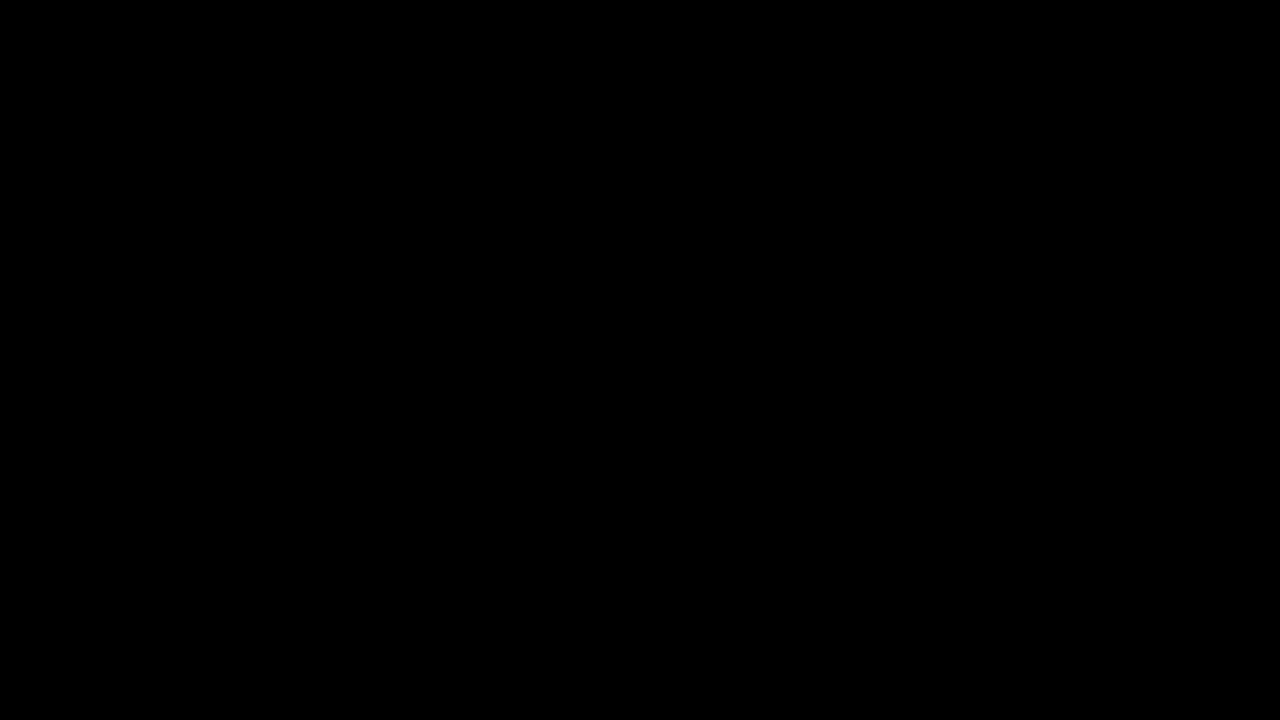

In [ ]:
%%manim -qm -v WARNING LogisticUncertainty


class LogisticUncertainty(Scene):
    """Posterior draws of logistic curves showing classification uncertainty."""

    def construct(self):
        rng_m = np.random.default_rng(99)

        # --- Title ---
        title = Text(
            "Bayesian Logistic Regression: Posterior Uncertainty",
            font_size=28,
            color=C.LABEL,
        )
        title.to_edge(UP, buff=0.3)
        self.play(Write(title), run_time=0.8)

        # --- Generate 1D data for visualisation ---
        n_data = 60
        x_data = rng_m.normal(0, 1.8, n_data)
        alpha_gen, beta_gen = 0.3, 1.4
        p_data = 1.0 / (1.0 + np.exp(-(alpha_gen + beta_gen * x_data)))
        y_data = rng_m.binomial(1, p_data)

        # --- Axes ---
        axes = Axes(
            x_range=[-5, 5, 1],
            y_range=[-0.1, 1.1, 0.2],
            x_length=10,
            y_length=5,
            axis_config={"color": C.NEUTRAL, "stroke_width": 1.5},
            tips=False,
        ).shift(DOWN * 0.3)

        x_lab = Text("x", font_size=20, color=C.LABEL).next_to(
            axes.x_axis, RIGHT, buff=0.2
        )
        y_lab = Text("P(y=1|x)", font_size=20, color=C.LABEL).next_to(
            axes.y_axis, UP, buff=0.2
        )
        self.play(Create(axes), Write(x_lab), Write(y_lab), run_time=1.0)

        # --- Plot data points ---
        dots = VGroup()
        for xi, yi in zip(x_data, y_data):
            color = C.SALMON if yi == 1 else C.PERIWINKLE
            y_pos = yi + rng_m.uniform(-0.03, 0.03)  # small jitter
            dot = Dot(axes.c2p(xi, y_pos), radius=0.05, color=color, fill_opacity=0.7)
            dots.add(dot)

        # Legend
        leg_0 = Dot(color=C.PERIWINKLE, radius=0.06).shift(RIGHT * 3.5 + UP * 2.8)
        leg_0_text = Text("y = 0", font_size=16, color=C.PERIWINKLE).next_to(
            leg_0, RIGHT, buff=0.15
        )
        leg_1 = Dot(color=C.SALMON, radius=0.06).next_to(leg_0, DOWN, buff=0.2)
        leg_1_text = Text("y = 1", font_size=16, color=C.SALMON).next_to(
            leg_1, RIGHT, buff=0.15
        )

        self.play(
            FadeIn(dots),
            FadeIn(leg_0),
            Write(leg_0_text),
            FadeIn(leg_1),
            Write(leg_1_text),
            run_time=1.5,
        )
        self.wait(0.5)

        # --- Draw posterior samples of logistic curves ---
        # Simulate approximate posterior draws (for visualisation)
        n_draws = 40
        alpha_draws = rng_m.normal(alpha_gen, 0.35, n_draws)
        beta_draws = rng_m.normal(beta_gen, 0.30, n_draws)

        x_curve = np.linspace(-5, 5, 150)

        posterior_lines = VGroup()
        draw_label = Text("Posterior draws", font_size=18, color=C.NEUTRAL)
        draw_label.move_to(axes.c2p(-3.5, 0.85))
        self.play(Write(draw_label), run_time=0.5)

        for i in range(n_draws):
            p_curve = 1.0 / (1.0 + np.exp(-(alpha_draws[i] + beta_draws[i] * x_curve)))
            points = [axes.c2p(x, p) for x, p in zip(x_curve, p_curve)]
            line = VMobject()
            line.set_points_smoothly(points)
            line.set_stroke(color=C.NEUTRAL, width=1.0, opacity=0.25)
            posterior_lines.add(line)

        # Animate in batches
        batch_size = 10
        for start in range(0, n_draws, batch_size):
            batch = posterior_lines[start : start + batch_size]
            self.play(*[Create(l) for l in batch], run_time=0.8)

        self.wait(0.3)

        # --- Posterior mean curve ---
        p_mean = 1.0 / (
            1.0 + np.exp(-(np.mean(alpha_draws) + np.mean(beta_draws) * x_curve))
        )
        points_mean = [axes.c2p(x, p) for x, p in zip(x_curve, p_mean)]
        mean_line = VMobject()
        mean_line.set_points_smoothly(points_mean)
        mean_line.set_stroke(color=C.GOLD, width=3.5, opacity=1.0)

        mean_label = Text("Posterior mean", font_size=18, color=C.GOLD)
        mean_label.move_to(axes.c2p(2.5, 0.55))

        self.play(Create(mean_line), Write(mean_label), run_time=1.5)
        self.wait(0.5)

        # --- Highlight uncertainty region ---
        note = Text(
            "Spread = uncertainty in the decision boundary", font_size=20, color=C.LABEL
        ).to_edge(DOWN, buff=0.3)
        self.play(Write(note), run_time=1.0)
        self.wait(2)

The animation shows how the posterior uncertainty manifests: near the centre of the data, all posterior logistic curves agree closely. In the tails (extreme $x$ values), the curves fan out — the model is less sure about the probability of $y = 1$ for patients with unusual predictor values. The gold curve is the posterior mean; the semi-transparent grey curves are individual posterior draws.

---

## 8. Comparison with Frequentist Logistic Regression

The standard frequentist approach (e.g., `sklearn.linear_model.LogisticRegression`) uses **maximum likelihood estimation (MLE)** to find point estimates $\hat{\alpha}, \hat{\boldsymbol{\beta}}$. Let us compare.

In [ ]:
if LogisticRegression is not None:
    X_sklearn = np.column_stack([age, dosage])
    clf = LogisticRegression(C=1e10, max_iter=1000)
    clf.fit(X_sklearn, y_response)

    print("Frequentist MLE (sklearn):")
    print(f"  Intercept: {clf.intercept_[0]:+.3f}")
    print(f"  beta_age:  {clf.coef_[0, 0]:+.3f}")
    print(f"  beta_dose: {clf.coef_[0, 1]:+.3f}")
    print()

    if pm is not None and az is not None:
        post = trace.posterior
        print("Bayesian posterior medians (PyMC):")
        print(f"  alpha:     {np.median(post['alpha'].values):+.3f}")
        print(f"  beta_age:  {np.median(post['beta_age'].values):+.3f}")
        print(f"  beta_dose: {np.median(post['beta_dose'].values):+.3f}")
        print()

    print(
        f"True values: alpha={alpha_true:+.3f}, beta_age={beta_age_true:+.3f}, beta_dose={beta_dose_true:+.3f}"
    )
else:
    print("scikit-learn not available — skipping.")

Frequentist MLE (sklearn):
  Intercept: -0.634
  beta_age:  -0.409
  beta_dose: +1.589

Bayesian posterior medians (PyMC):
  alpha:     -0.613
  beta_age:  -0.385
  beta_dose: +1.488

True values: alpha=-0.500, beta_age=-0.300, beta_dose=+1.500


With $n = 120$ observations and well-separated classes, the MLE and posterior median are very close. The key differences emerge in specific scenarios:

### When does the Bayesian approach matter?

| Scenario                       | Frequentist problem                                                                                           | Bayesian advantage                                                              |
|--------------------------------|---------------------------------------------------------------------------------------------------------------|---------------------------------------------------------------------------------|
| **Small $n$**                  | MLE is unstable, confidence intervals rely on asymptotics that may not hold                                   | Posterior is exact (given the model); priors regularise naturally               |
| **Class imbalance**            | MLE can be undefined if one class has no observations at certain covariate levels (complete/quasi-separation) | Priors prevent infinite coefficients                                            |
| **Informative priors**         | Cannot incorporate prior knowledge (or must use ad hoc regularisation like $\ell_2$ penalty)                  | Domain knowledge enters formally through priors                                 |
| **Uncertainty quantification** | Confidence intervals are frequentist (coverage guarantees over repeated sampling)                             | Credible intervals directly express probability given the data                  |
| **Decision-making**            | Point prediction only; uncertainty requires bootstrap or profile likelihood                                   | Full predictive distribution feeds naturally into expected utility calculations |

### Complete separation: where MLE breaks

If there exists a hyperplane that perfectly separates the two classes, the MLE does not exist — the log-likelihood is maximised at $\beta \to \pm\infty$. In practice, `sklearn` will converge to very large coefficients with spurious precision. Bayesian priors prevent this by penalising extreme parameter values.

In [ ]:
# Demonstration: complete separation with small n
x_sep = np.array([-2, -1.5, -1, -0.5, 0.5, 1, 1.5, 2])
y_sep = np.array([0, 0, 0, 0, 1, 1, 1, 1])  # perfect separation

if LogisticRegression is not None:
    clf_sep = LogisticRegression(C=1e10, max_iter=5000)
    clf_sep.fit(x_sep.reshape(-1, 1), y_sep)
    print("MLE with complete separation:")
    print(f"  Intercept: {clf_sep.intercept_[0]:+.2f}")
    print(f"  beta:      {clf_sep.coef_[0, 0]:+.2f}")
    print(f"  (Note: these are artificially large — MLE diverges.)")

if pm is not None:
    with pm.Model() as sep_model:
        a = pm.Normal("a", mu=0, sigma=5)
        b = pm.Normal("b", mu=0, sigma=1)
        pm.Bernoulli("y", logit_p=a + b * x_sep, observed=y_sep)
        trace_sep = pm.sample(2000, chains=4, random_seed=42, return_inferencedata=True)

    post_sep = trace_sep.posterior
    print(f"\nBayesian with separation (prior: N(0,1)):")
    print(f"  alpha median: {np.median(post_sep['a'].values):+.2f}")
    print(f"  beta median:  {np.median(post_sep['b'].values):+.2f}")
    print(
        f"  beta 94% HDI: [{np.percentile(post_sep['b'].values, 3):.2f}, {np.percentile(post_sep['b'].values, 97):.2f}]"
    )
    print(f"  (Sensible: prior prevents explosion.)")

Initializing NUTS using jitter+adapt_diag...
# 2026-03-20 00:09:06,327 INFO pymc.sampling.mcmc mcmc.py:1659 -- Initializing NUTS using jitter+adapt_diag...



MLE with complete separation:
  Intercept: +0.00
  beta:      +14.55
  (Note: these are artificially large — MLE diverges.)


Multiprocess sampling (4 chains in 4 jobs)
# 2026-03-20 00:09:06,711 INFO pymc.sampling.mcmc mcmc.py:959 -- Multiprocess sampling (4 chains in 4 jobs)

NUTS: [a, b]
# 2026-03-20 00:09:06,711 INFO pymc.sampling.mcmc mcmc.py:314 -- NUTS: [a, b]



Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 38 seconds.
# 2026-03-20 00:09:44,992 INFO pymc.sampling.mcmc mcmc.py:1142 -- Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 38 seconds.




Bayesian with separation (prior: N(0,1)):
  alpha median: +0.00
  beta median:  +1.57
  beta 94% HDI: [0.45, 2.95]
  (Sensible: prior prevents explosion.)


---

## 9. Extensions: The Generalised Linear Model Family

Logistic regression is one member of a large family: **generalised linear models (GLMs)**. The Bayesian pattern is always the same:

$$\boxed{\begin{aligned}
y &\sim \text{Distribution}(\theta) \\
g(\theta) &= \alpha + \mathbf{x}^\top \boldsymbol{\beta} \\
\alpha, \boldsymbol{\beta} &\sim \text{Priors}
\end{aligned}}$$

where $g$ is the **link function** and the distribution is from the **exponential family**.

### Probit regression

Replace the logistic function with the **standard normal CDF** $\Phi$:

$$p_i = \Phi(\alpha + \mathbf{x}_i^\top \boldsymbol{\beta})$$

The probit link maps $\mathbb{R} \to (0, 1)$ just like the logistic, but with slightly thinner tails. In practice, logistic and probit regressions give very similar results. The probit arises naturally in latent variable formulations: if there is an unobserved continuous variable $z \sim \mathcal{N}(\eta, 1)$ and we observe $y = \mathbb{1}(z > 0)$, then $P(y = 1) = \Phi(\eta)$.

### Poisson regression (log link)

For **count data** ($y \in \{0, 1, 2, \ldots\}$):

$$y \sim \text{Poisson}(\lambda), \qquad \log(\lambda) = \alpha + \mathbf{x}^\top \boldsymbol{\beta}$$

The **log link** ensures $\lambda > 0$. Coefficients are interpreted on the log-rate scale: $e^{\beta_j}$ is the **rate ratio** (analogous to the odds ratio in logistic regression).

### Ordinal regression (cumulative logit)

For **ordered categorical** outcomes ($y \in \{1, 2, \ldots, K\}$, e.g., pain severity: none/mild/moderate/severe):

$$\text{logit}(P(y \leq k)) = \alpha_k - \mathbf{x}^\top \boldsymbol{\beta}$$

There are $K - 1$ threshold parameters $\alpha_1 < \alpha_2 < \cdots < \alpha_{K-1}$. The model generalises logistic regression by modelling cumulative probabilities.

In each case, the Bayesian approach is identical: place priors on the parameters, sample the posterior with MCMC, and interpret. PyMC supports all of these distributions natively.

---

## Exercises

**Exercise 2.1 (Prior sensitivity).** Using the clinical trial data from Section 5, re-fit the Bayesian logistic model with three different priors on `beta_dose`: (a) $\mathcal{N}(0, 0.5)$ (strong), (b) $\mathcal{N}(0, 1)$ (moderate, our default), (c) $\mathcal{N}(0, 10)$ (vague). Compare the posterior distributions of `beta_dose` under each prior. How much does the prior matter with $n = 120$? Repeat with $n = 20$ (subsample the data). When does the prior dominate?

**Exercise 2.2 (Odds ratio interpretation).** A study finds that the posterior median of $\beta_{\text{exercise}}$ in a heart disease model is $-0.6$ with a 94% HDI of $[-1.0, -0.2]$. (a) Compute the odds ratio and its HDI. (b) Write a one-sentence clinical interpretation. (c) If the baseline probability of heart disease is 0.15, what is the approximate probability after a one-unit increase in exercise? Compute exactly using the logistic function.

**Exercise 2.3 (Posterior predictive calibration).** Using the fitted model from Section 5, compute posterior predictive probabilities $P(y = 1 \mid x)$ for all patients in the training set. Bin the posterior mean probabilities into deciles and compute the observed proportion of $y = 1$ in each bin. Plot predicted vs. observed proportions. Is the model well-calibrated?

**Exercise 2.4 (Complete separation).** Generate a dataset with $n = 12$ and **complete separation**: all $y = 0$ when $x < 0$ and all $y = 1$ when $x > 0$. (a) Fit a frequentist logistic regression and report the coefficients. (b) Fit a Bayesian logistic regression with $\beta \sim \mathcal{N}(0, 1)$. Compare the coefficient estimates and discuss. (c) Try $\beta \sim \mathcal{N}(0, 10)$ — does the problem return?

**Exercise 2.5 (Poisson extension).** Simulate count data: $y_i \sim \text{Poisson}(\lambda_i)$ where $\log \lambda_i = 1.0 + 0.5 x_i$ and $x_i \sim \mathcal{N}(0, 1)$ for $n = 100$. Build a Bayesian Poisson regression in PyMC. Sample the posterior, check diagnostics, and verify that the posterior recovers the true coefficients. Interpret $e^{\hat{\beta}}$ as a rate ratio.

---

## Key Takeaways

1. **Binary outcomes need a link function.** Linear regression predicts outside $[0, 1]$; the logistic function maps the linear predictor to a valid probability.

2. **The logit is the inverse of the logistic.** It maps probabilities to log-odds. The logistic regression model is linear in log-odds: $\text{logit}(p) = \alpha + \mathbf{x}^\top \boldsymbol{\beta}$.

3. **Coefficients are log-odds changes.** $\beta_j$ is the change in log-odds per unit change in $x_j$. Exponentiate for odds ratios: $\text{OR} = e^{\beta_j}$.

4. **Bayesian logistic regression has no $\sigma$ parameter.** The Bernoulli variance is $p(1-p)$, fully determined by $p$. Priors go only on $\alpha$ and $\boldsymbol{\beta}$.

5. **The posterior is not analytically tractable** (unlike conjugate models). We must use MCMC, which PyMC handles automatically via NUTS.

6. **Posterior predictive gives calibrated uncertainty.** Instead of a single predicted probability, we get a full distribution of $P(y=1 \mid x_{\text{new}})$, crucial for honest decision-making.

7. **Bayesian priors prevent pathologies** like complete separation, where the MLE diverges to infinity. This is a practical advantage with small or imbalanced datasets.

8. **Logistic regression is one GLM among many.** Probit (for binary), Poisson (for counts), and ordinal models follow the same Bayesian pattern: distribution + link + priors.

---

**Next:** [03_model_comparison.ipynb](03_model_comparison.ipynb) — Bayesian model comparison using WAIC, LOO-CV, and Bayes factors.

In [27]:
cfg.save_gifs(clean=True)

  ✓ media/gifs/LogisticUncertainty@2026-03-20@00-01-16.gif
  ✓ media/gifs/PosteriorPredictive@2026-03-19@22-26-01.gif
  ✓ media/gifs/LogisticUncertainty_ManimCE_v0.18.1.gif
  Cleaned up local temp render files (kept media/jupyter/).
